In [1]:
import numpy as np
import scipy as sp
import scipy.signal as signal
import matplotlib.pyplot as plt

In [22]:
def x(t):
	if abs(t) <= 1:
		return 1 - abs(t)
	else:
		return 0

fs_10 = 10  # Taxa de amostragem de 10 Hz
Ts_10 = 1/fs_10  # Período de amostragem (0.1 s)
t_10 = np.arange(0, 2 + Ts_10, Ts_10)  # Intervalo de tempo (0 a 2 s)

plt.figure(figsize=(10, 6))
plt.plot(t_10, x(t_10))
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Sinal x(t) Amostrado com 10 Hz')
plt.legend()
plt.grid(True)
plt.show()


IndexError: arrays used as indices must be of integer (or boolean) type

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def rect(t):
	return np.where(np.abs(t) <= 0.5, 1.0, 0.0)

def x_t(t):
	return rect((t - 1) / 2)

def sample_signal(f_s, t_start=0, t_end=2):
	T_s = 1 / f_s
	t_samples = np.arange(t_start, t_end + T_s, T_s)
	x_samples = x_t(t_samples)
	return t_samples, x_samples

# Amostrando o sinal nas taxas de 10 Hz, 2 Hz e 1 Hz
fs_list = [10, 2, 1]
t_cont = np.linspace(0, 2, 1000)
x_cont = x_t(t_cont)

plt.figure(figsize=(15, 10))

for i, fs in enumerate(fs_list, 1):
	t_samples, x_samples = sample_signal(fs)
	plt.subplot(3, 1, i)
	plt.plot(t_cont, x_cont, label='x(t)', color='blue')
	plt.stem(t_samples, x_samples, 'r', markerfmt='ro', basefmt='r-', label=f'Amostras a {fs} Hz')
	plt.title(f'Sinal amostrado a {fs} Hz')
	plt.xlabel('Tempo (s)')
	plt.ylabel('Amplitude')
	plt.legend()
	plt.grid(True)

plt.tight_layout()
plt.show()


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

/tmp/ipykernel_3326/1788410734.py:18: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(t_n, x_n, use_line_collection=True)


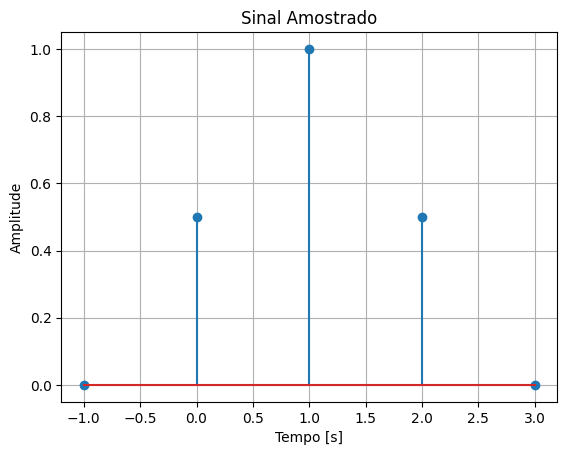

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def x(t):
	return np.maximum(0, 1 - np.abs((t - 1) / 2))

# Definindo a taxa de amostragem
fs = 1  # Hz
Ts = 1 / fs  # Período de amostragem

# Definindo o intervalo de tempo para amostragem
t_n = np.arange(-1, 3 + Ts, Ts)

# Calculando as amostras
x_n = x(t_n)

# Plotando o sinal amostrado
plt.stem(t_n, x_n, use_line_collection=True)
plt.title('Sinal Amostrado')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


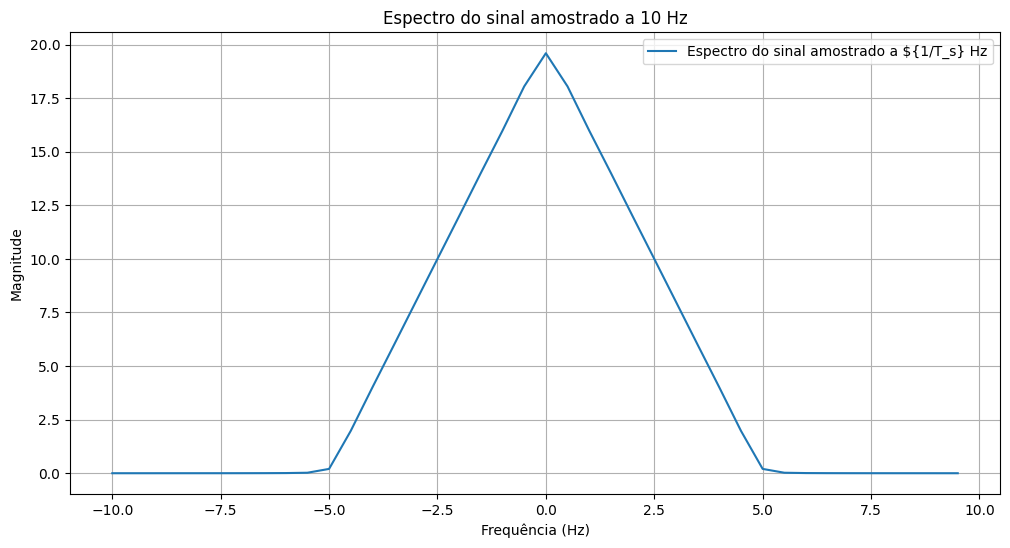

In [39]:
import numpy as np
from scipy.fftpack import fft, fftshift

# Definição do sinal x(t)
def x(t):
    return 5 * (np.sinc(5 * t)**2) + np.sin(20 * np.pi * t)

# Pontos de tempo para o sinal contínuo e amostragem
T_s = 0.0476190476190476  # Período de amostragem para 10 Hz
t = np.arange(-1, 1, T_s)  # Tempo variando de -1 a 1 segundo com passos de T_s
x_t = x(t)

# FFT do sinal amostrado
X_f = fft(x_t)
X_f_shifted = fftshift(X_f)  # Shift para centrar a frequência zero
frequencies = fftshift(np.fft.fftfreq(len(X_f), T_s))

# Plotar o espectro do sinal amostrado
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(X_f_shifted), label='Espectro do sinal amostrado a ${1/T_s} Hz')
plt.title('Espectro do sinal amostrado a 10 Hz')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.legend()
plt.show()
